Title : HCAHPS Patient Experience Analysis

1. Project Goal
Evaluating Hospital Patient Experience Using HCAHPS Survey Data. Explore patterns, trends, and key drivers of patient experience in U.S. hospitals using HCAHPS survey data.

1.1 Project Overview
Describe what HCAHPS is: a national, standardized survey about hospital patient experience.
Explain why patient experience matters (quality of care, safety, transparency).

1.2 Probem Statement
Patients and policymakers often struggle to understand how hospital experiences vary across states and hospital types. This project uses HCAHPS data to answer:
- How do hospitals differ in patient experience scores?
- Which areas (communication, environment, responsiveness) score highest and lowest?
- Are there geographic patterns in patient satisfaction?
- Which hospitals stand out as top or bottom performers?

2. Datasets 
Dataset used: Patient Survey (HCAHPS) – Hospital
("C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\Capstone 2 - EDA\HCAHPS-Hospital.csv")

Data Dictonary : "C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\Capstone 2 - EDA\HOSPITAL_Data_Dictionary.pdf"

Includes:
- Facility ID, Facility Name, State
- HCAHPS measure ID and question
- Linear scores or percent scores
- Star ratings
- Survey response rates
- Reporting period dates

3. Methodology

3.1 Data Cleaning
- Load dataset
- Keep relevant columns
- Convert dates
- Filter to latest reporting period (optional)
- Handle missing values
- Normalize column names
- Convert scores to numeric

3.2 Data Analysis Steps

- Descriptive statistics
- Distribution of patient experience scores
- Compare scores by state
- Compare scores by measure category
- Identify top and bottom 10 hospitals
- Correlation analysis (e.g., communication vs overall rating)
- Response rate analysis

4. Visualizations

- Bar charts of average scores by question
- Heatmap of correlations between HCAHPS measures
- Boxplots of scores by state or region
- Histogram of overall ratings
- Scatterplot: communication linear score vs overall rating
- Choropleth map of average scores 

5. Key Questions to Explore

- Which patient experience categories score lowest nationally?
- Do certain regions consistently score higher?
- Are there hospitals that consistently outperform others across multiple categories?
- How does survey response rate affect scores?

6. Deliverables

- Jupyter Notebook with EDA
- Presentation slides (overview, methods, insights, recommendations)
- Cleaned dataset (optional)


In [23]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid", context="notebook")

In [24]:
# Input data file path
DATA_PATH = "C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\Capstone 2 - EDA\\HCAHPS-Hospital.csv"

# Optional: output folder
OUTPUT_DIR = "outputs_hcahps"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [25]:
#Load the dataset
df = pd.read_csv(DATA_PATH)
usecols = None  # load all columns; set a list if you want a subset
dtype_map = {
    "Facility ID": "string",  # preserve leading zeros (e.g., 010001)
    "State": "string",
}

hcahps = pd.read_csv(DATA_PATH, dtype=dtype_map, usecols=usecols, low_memory=False)

# Basic cleaning
hcahps["Facility ID"] = hcahps["Facility ID"].str.strip()
for col in ["Facility Name", "City/Town", "State"]:
    if col in hcahps.columns:
        hcahps[col] = hcahps[col].astype("string").str.strip()

# Convert numeric columns safely
num_cols = [
    "HCAHPS Answer Percent", "HCAHPS Linear Mean Value",
    "Patient Survey Star Rating", "Number of Completed Surveys",
    "Survey Response Rate Percent"
]
for c in num_cols:
    if c in hcahps.columns:
        hcahps[c] = pd.to_numeric(hcahps[c], errors="coerce")

# Parse dates
for d in ["Start Date", "End Date"]:
    if d in hcahps.columns:
        hcahps[d] = pd.to_datetime(hcahps[d], errors="coerce")

print(hcahps.shape)
hcahps.head(3)

C:\Users\VBACOMishrR\AppData\Local\Temp\1\ipykernel_30576\2678735800.py:2: DtypeWarning: Columns (12,14,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


(325652, 22)


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,HCAHPS Measure ID,HCAHPS Question,HCAHPS Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_A_P,"Patients who reported that their nurses ""Alway...","Nurses ""always"" communicated well",NaN,NaN,75.0,NaN,NaN,596.0,NaN,16.0,NaN,2024-04-01,2025-03-31
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_SN_P,"Patients who reported that their nurses ""Somet...","Nurses ""sometimes"" or ""never"" communicated well",NaN,NaN,6.0,NaN,NaN,596.0,NaN,16.0,NaN,2024-04-01,2025-03-31
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_U_P,"Patients who reported that their nurses ""Usual...","Nurses ""usually"" communicated well",NaN,NaN,19.0,NaN,NaN,596.0,NaN,16.0,NaN,2024-04-01,2025-03-31


In [26]:
#Peek at Measures & Choose Focus
print("Unique HCAHPS Measures:")
print(hcahps["HCAHPS Measure ID"].unique())
# What measures are available?
measure_counts = (hcahps["HCAHPS Measure ID"]
                  .value_counts(dropna=False)
                  .rename_axis("HCAHPS Measure ID")
                  .reset_index(name="rows"))
measure_counts.head(10)

# We'll define a preferred set of measures and then take whichever are present.
preferred_measures = [
    # Linear mean scores (often more stable)
    "H_COMP_1_LINEAR_SCORE",  # Nurse communication - linear mean score
    "H_COMP_2_LINEAR_SCORE",  # Doctor communication - linear mean score
    # Percent-based overall ratings/recommendation (IDs may vary by release)
    "H_HSP_RATING_9_10_P",    # % rating hospital 9 or 10
    "H_RECMND_DN_P",          # % would "definitely recommend"
]

available_measures = set(hcahps["HCAHPS Measure ID"].dropna().unique())
focus_measures = [m for m in preferred_measures if m in available_measures]

# Fallbacks if not all preferred measures exist
if not focus_measures:
    # choose any linear scores first, else any percent measures
    linear_like = [m for m in available_measures if "LINEAR_SCORE" in str(m)]
    percent_like = [m for m in available_measures if str(m).endswith("_P")]
    focus_measures = (linear_like[:2] + percent_like[:2]) or list(available_measures)[:4]

focus_measures

Unique HCAHPS Measures:
['H_COMP_1_A_P' 'H_COMP_1_SN_P' 'H_COMP_1_U_P' 'H_COMP_1_LINEAR_SCORE'
 'H_COMP_1_STAR_RATING' 'H_NURSE_RESPECT_A_P' 'H_NURSE_RESPECT_SN_P'
 'H_NURSE_RESPECT_U_P' 'H_NURSE_LISTEN_A_P' 'H_NURSE_LISTEN_SN_P'
 'H_NURSE_LISTEN_U_P' 'H_NURSE_EXPLAIN_A_P' 'H_NURSE_EXPLAIN_SN_P'
 'H_NURSE_EXPLAIN_U_P' 'H_COMP_2_A_P' 'H_COMP_2_SN_P' 'H_COMP_2_U_P'
 'H_COMP_2_LINEAR_SCORE' 'H_COMP_2_STAR_RATING' 'H_DOCTOR_RESPECT_A_P'
 'H_DOCTOR_RESPECT_SN_P' 'H_DOCTOR_RESPECT_U_P' 'H_DOCTOR_LISTEN_A_P'
 'H_DOCTOR_LISTEN_SN_P' 'H_DOCTOR_LISTEN_U_P' 'H_DOCTOR_EXPLAIN_A_P'
 'H_DOCTOR_EXPLAIN_SN_P' 'H_DOCTOR_EXPLAIN_U_P' 'H_COMP_5_A_P'
 'H_COMP_5_SN_P' 'H_COMP_5_U_P' 'H_COMP_5_LINEAR_SCORE'
 'H_COMP_5_STAR_RATING' 'H_MED_FOR_A_P' 'H_MED_FOR_SN_P' 'H_MED_FOR_U_P'
 'H_SIDE_EFFECTS_A_P' 'H_SIDE_EFFECTS_SN_P' 'H_SIDE_EFFECTS_U_P'
 'H_COMP_6_N_P' 'H_COMP_6_Y_P' 'H_COMP_6_LINEAR_SCORE'
 'H_COMP_6_STAR_RATING' 'H_DISCH_HELP_N_P' 'H_DISCH_HELP_Y_P'
 'H_SYMPTOMS_N_P' 'H_SYMPTOMS_Y_P' 'H_CLEAN_HSP_A_

['H_COMP_1_LINEAR_SCORE', 'H_COMP_2_LINEAR_SCORE']

In [27]:
#Latest Reporting Period per Hospital + Measure
hcahps["Reporting Period"] = hcahps["Start Date"].dt.to_period("Q")
latest_periods = (hcahps.groupby(["Facility ID", "HCAHPS Measure ID"])["Reporting Period"]
                  .max()
                  .reset_index()
                  .rename(columns={"Reporting Period": "Latest Period"}))  
latest_data = pd.merge(hcahps, latest_periods, on=["Facility ID", "HCAHPS Measure ID"])
latest_data = latest_data[latest_data["Reporting Period"] == latest_data["Latest Period"]]
latest_data = latest_data.drop(columns=["Latest Period"])
print(latest_data.shape)
latest_data.head(3)
# Sort by End Date so the last is the most recent per facility+measure
hc_sorted = hcahps.sort_values(["Facility ID", "HCAHPS Measure ID", "End Date"])

# Keep latest per Facility ID + Measure ID
hc_latest = hc_sorted.drop_duplicates(["Facility ID", "HCAHPS Measure ID"], keep="last")

print(hc_latest["End Date"].min(), hc_latest["End Date"].max())
hc_latest.shape

(325652, 23)
2025-03-31 00:00:00 2025-03-31 00:00:00


(325652, 23)

In [28]:
#Build a Wide Table for the Focus Measures(one row per hospital, columns for each measure)
# Select just the focus measures + key descriptors
keep_cols = ["Facility ID", "Facility Name", "State", "HCAHPS Measure ID",
             "HCAHPS Answer Percent", "HCAHPS Linear Mean Value",
             "Patient Survey Star Rating", "Number of Completed Surveys",
             "Survey Response Rate Percent"]

hc_focus = hc_latest[hc_latest["HCAHPS Measure ID"].isin(focus_measures)].copy()
hc_focus = hc_focus[keep_cols]

# Prefer "Linear Mean Value" when available; otherwise use "Answer Percent"
def value_col_for_row(row):
    if pd.notna(row.get("HCAHPS Linear Mean Value")):
        return row["HCAHPS Linear Mean Value"]
    return row.get("HCAHPS Answer Percent")

hc_focus["measure_value"] = hc_focus.apply(value_col_for_row, axis=1)

hc_wide = (hc_focus
           .pivot_table(index=["Facility ID", "Facility Name", "State"],
                        columns="HCAHPS Measure ID", values="measure_value", aggfunc="mean")
           .reset_index())

print(hc_wide.shape)
hc_wide.head(3)

(3183, 5)


HCAHPS Measure ID,Facility ID,Facility Name,State,H_COMP_1_LINEAR_SCORE,H_COMP_2_LINEAR_SCORE
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,90.0,92.0
1,010005,MARSHALL MEDICAL CENTERS,AL,91.0,93.0
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,89.0,88.0


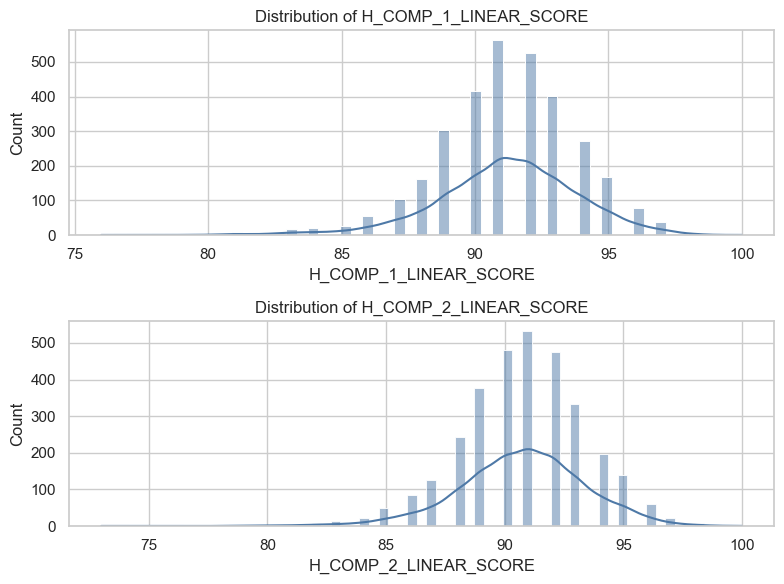

In [29]:
#Descriptive Statistics & Distributions
hc_wide.describe()
# Summary stats for chosen measures
desc = hc_wide[focus_measures].describe().T
desc["missing_pct"] = hc_wide[focus_measures].isna().mean()
desc

# Histograms
fig, axes = plt.subplots(nrows=len(focus_measures), ncols=1, figsize=(8, 3*len(focus_measures)))
if len(focus_measures) == 1:
    axes = [axes]
for ax, m in zip(axes, focus_measures):
    sns.histplot(hc_wide[m], kde=True, ax=ax, color="#4e79a7")
    ax.set_title(f"Distribution of {m}")
plt.tight_layout()
plt.show()

In [30]:
#State-Level Averages
state_means = hc_wide.groupby("State")[focus_measures].mean().reset_index()
state_means.head(3)
# State-level average across selected measures (simple mean)
df_state = (hc_wide
            .groupby("State")[focus_measures].mean()
            .reset_index())

df_state.head()
# Choropleth on one headline measure (pick the first available)
choropleth_measure = focus_measures[0]
fig = px.choropleth(
    df_state,
    locations="State",
    locationmode="USA-states",
    color=choropleth_measure,
    scope="usa",
    color_continuous_scale="Blues",
    labels={choropleth_measure: choropleth_measure.replace("_", " ")},
    title=f"Average {choropleth_measure} by State (Latest Reporting Period)"
)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()


In [31]:
# Top & Bottom Hospitals
rank_measure = focus_measures[0]  # choose any measure; pick first by default

top10 = (hc_wide
         .dropna(subset=[rank_measure])
         .sort_values(rank_measure, ascending=False)
         .head(10)
         .reset_index(drop=True))

bottom10 = (hc_wide
            .dropna(subset=[rank_measure])
            .sort_values(rank_measure, ascending=True)
            .head(10)
            .reset_index(drop=True))

print("Top 10 hospitals by", rank_measure)
top10[["Facility Name", "State", rank_measure]]

print("\nBottom 10 hospitals by", rank_measure)
bottom10[["Facility Name", "State", rank_measure]]

Top 10 hospitals by H_COMP_1_LINEAR_SCORE

Bottom 10 hospitals by H_COMP_1_LINEAR_SCORE


HCAHPS Measure ID,Facility Name,State,H_COMP_1_LINEAR_SCORE
0,COAST PLAZA HOSPITAL,CA,76.0
1,LOS ANGELES COMMUNITY HOSPITAL,CA,78.0
2,ST JOSEPH'S MEDICAL CENTER,NY,79.0
3,SOUTHERN CALIFORNIA HOSPITAL AT HOLLYWOOD,CA,80.0
4,SINAI-GRACE HOSPITAL,MI,80.0
5,DELRAY MEDICAL CENTER,FL,81.0
6,ROSELAND COMMUNITY HOSPITAL,IL,81.0
7,GALLUP INDIAN MEDICAL CENTER,NM,81.0
8,LOUIS A WEISS MEMORIAL HOSPITAL,IL,81.0
9,ST JOHN'S EPISCOPAL HOSPITAL AT SOUTH SHORE,NY,81.0


In [32]:
# Weighted State Averages (by Completed Surveys)
# Build long table with chosen measure values and weights (completed surveys)
long_focus = hc_focus[hc_focus["HCAHPS Measure ID"].isin(focus_measures)].copy()
long_focus["value"] = long_focus.apply(value_col_for_row, axis=1)
long_focus["weight"] = long_focus["Number of Completed Surveys"].fillna(0)

weighted = (long_focus
            .groupby(["State", "HCAHPS Measure ID"])
            .apply(lambda g: np.average(g["value"], weights=g["weight"]) if g["weight"].sum() > 0 else g["value"].mean())
            .rename("weighted_avg")
            .reset_index())

weighted_pivot = (weighted
                  .pivot_table(index="State", columns="HCAHPS Measure ID", values="weighted_avg")
                  .reset_index())
weighted_pivot.head()

C:\Users\VBACOMishrR\AppData\Local\Temp\1\ipykernel_30576\2987963288.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["value"], weights=g["weight"]) if g["weight"].sum() > 0 else g["value"].mean())


HCAHPS Measure ID,State,H_COMP_1_LINEAR_SCORE,H_COMP_2_LINEAR_SCORE
0,RI,92.055208,91.679732


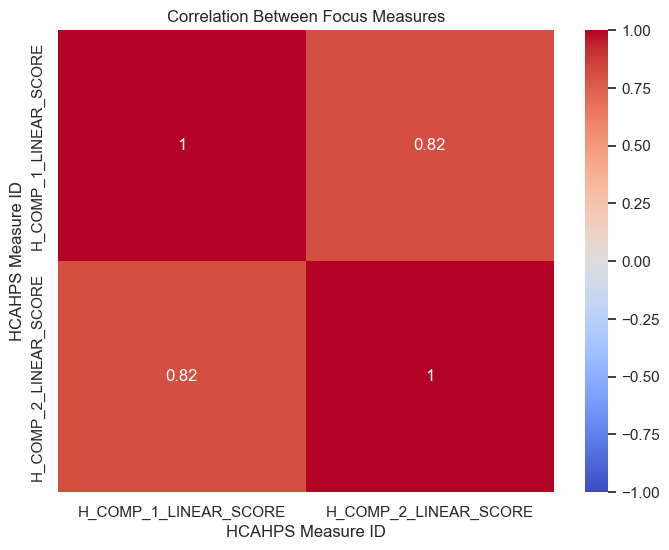

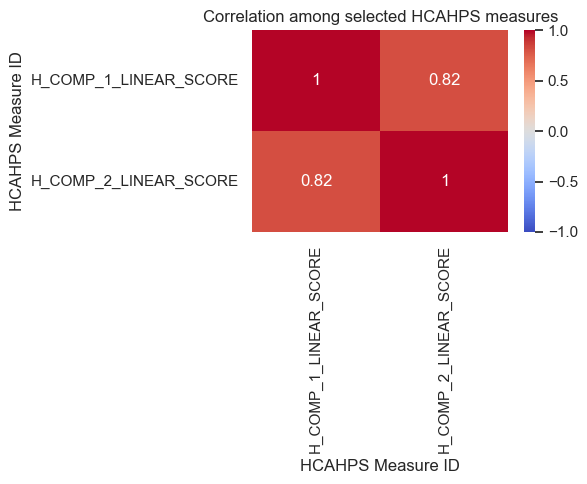

In [33]:
#Correlation between measures
corr = hc_wide[focus_measures].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Focus Measures")
plt.show()
corr_df = hc_wide[focus_measures].dropna(how="any")
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation among selected HCAHPS measures")
plt.tight_layout()
plt.show()

In [34]:
#Communication Measures vs Overall Rating
# Identify communication measures (example IDs; adjust as needed)
# Try to find a 'rating' or 'recommend' measure among your focus set
rating_candidates = [m for m in focus_measures if "RATING" in m or "RECMND" in m]
comm_candidates = [m for m in focus_measures if "COMP_1" in m or "COMP_2" in m]  # nurse or doctor communication

if rating_candidates and comm_candidates:
    x_m = comm_candidates[0]
    y_m = rating_candidates[0]
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=hc_wide, x=x_m, y=y_m, alpha=0.7)
    sns.regplot(data=hc_wide, x=x_m, y=y_m, scatter=False, color="red")
    plt.title(f"{y_m} vs {x_m}")
    plt.tight_layout()
    plt.show()
else:
    print("Rating or communication measures not found among focus set; adjust 'preferred_measures'.")

Rating or communication measures not found among focus set; adjust 'preferred_measures'.


Key Questions to Explore

In [ ]:
#Key Question to Explore

# Which patient experience categories have the lowest scores nationally?

# ---------------- Config ----------------
CSV_PATH = "HCAHPS-Hospital.csv"
ID_COLS = ["Facility ID", "HCAHPS Measure ID"]
DATE_COL = "End Date"

# Read data (preserve leading zeros in Facility ID)
hc = pd.read_csv(CSV_PATH, dtype={"Facility ID": "string"}, low_memory=False)

# Strip whitespace from key columns
for c in ["Facility ID", "HCAHPS Measure ID", "HCAHPS Question"]:
    if c in hc.columns:
        hc[c] = hc[c].astype("string").str.strip()

# Parse end date and keep latest period per facility+measure
hc[DATE_COL] = pd.to_datetime(hc[DATE_COL], errors="coerce")
hc_latest = (hc.sort_values(ID_COLS + [DATE_COL])
               .drop_duplicates(ID_COLS, keep="last"))

# Coerce numeric fields
for num_col in ["HCAHPS Linear Mean Value", "HCAHPS Answer Percent"]:
    if num_col in hc_latest.columns:
        hc_latest[num_col] = pd.to_numeric(hc_latest[num_col], errors="coerce")

# Value selection: prefer linear mean; else use answer percent
def pick_value(row):
    lm = row.get("HCAHPS Linear Mean Value")
    ap = row.get("HCAHPS Answer Percent")
    return lm if pd.notna(lm) else ap

hc_latest["measure_value"] = hc_latest.apply(pick_value, axis=1)

# ---------------- Category mapping ----------------
# This maps measure IDs to broader patient-experience categories
# Adjust or extend based on your file’s measure IDs.
category_map = {
    # Communication
    "H_COMP_1_LINEAR_SCORE": "Nurse Communication",
    "H_COMP_2_LINEAR_SCORE": "Doctor Communication",
    "H_COMP_5_LINEAR_SCORE": "Communication about Medicines",

    # Discharge information
    "H_COMP_6_LINEAR_SCORE": "Discharge Information",

    # Environment
    "H_CLEAN_LINEAR_SCORE": "Cleanliness",
    "H_QUIET_LINEAR_SCORE": "Quietness",

    # Global ratings / recommendation
    "H_HSP_RATING_LINEAR_SCORE": "Overall Hospital Rating",
    "H_RECMND_LINEAR_SCORE": "Recommend Hospital",
}

# Add category column
hc_latest["category"] = hc_latest["HCAHPS Measure ID"].map(category_map)

# Keep only rows that mapped to a category and have a value
cat_df = hc_latest.dropna(subset=["category", "measure_value"]).copy()

# ---------------- National averages per category ----------------
national_by_cat = (cat_df.groupby("category", as_index=False)["measure_value"]
                   .mean()
                   .rename(columns={"measure_value": "national_avg"}))

# Sort ascending (lowest scores nationally)
lowest_cats = national_by_cat.sort_values("national_avg", ascending=True)

print("National HCAHPS Patient-Experience Categories (Lowest to Highest):")
print(lowest_cats.to_string(index=False))

# Optionally: pretty print with rounding
lowest_cats_rounded = lowest_cats.copy()
lowest_cats_rounded["national_avg"] = lowest_cats_rounded["national_avg"].round(1)
print("\nRounded Averages:")
for _, r in lowest_cats_rounded.iterrows():
    print(f"- {r['category']}: {r['national_avg']}")

National HCAHPS Patient-Experience Categories (Lowest to Highest):
                     category  national_avg
Communication about Medicines     76.473139
                    Quietness     81.791078
        Discharge Information     85.742381
                  Cleanliness     86.607289
           Recommend Hospital     86.936538
      Overall Hospital Rating     87.933396
         Doctor Communication     90.715677
          Nurse Communication     91.207666

Rounded Averages:
- Communication about Medicines: 76.5
- Quietness: 81.8
- Discharge Information: 85.7
- Cleanliness: 86.6
- Recommend Hospital: 86.9
- Overall Hospital Rating: 87.9
- Doctor Communication: 90.7
- Nurse Communication: 91.2


We can assess that 'Communication about Medicines' is the lowest category. And we need to realize that Lower averages generally indicate improvement opportunities (e.g., Quietness and Cleanliness often score lower than communication items)

In [ ]:
#Key question to consider

#Do certain regions consistently score higher?

CSV_PATH = "HCAHPS-Hospital.csv"

# Read data; preserve leading zeros on Facility ID
hc = pd.read_csv(CSV_PATH, dtype={"Facility ID": "string"}, low_memory=False)

# Basic hygiene
for c in ["Facility ID", "HCAHPS Measure ID", "HCAHPS Question", "State"]:
    if c in hc.columns:
        hc[c] = hc[c].astype("string").str.strip()

# Dates: keep latest reporting period per facility+measure
hc["End Date"] = pd.to_datetime(hc["End Date"], errors="coerce")
hc_latest = (hc.sort_values(["Facility ID", "HCAHPS Measure ID", "End Date"])
               .drop_duplicates(["Facility ID", "HCAHPS Measure ID"], keep="last"))

# Coerce numeric fields
for num_col in ["HCAHPS Linear Mean Value", "HCAHPS Answer Percent", 
                "Number of Completed Surveys"]:
    if num_col in hc_latest.columns:
        hc_latest[num_col] = pd.to_numeric(hc_latest[num_col], errors="coerce")

# Prefer linear mean value; else answer percent
def pick_value(row):
    lm = row.get("HCAHPS Linear Mean Value")
    ap = row.get("HCAHPS Answer Percent")
    return lm if pd.notna(lm) else ap

hc_latest["measure_value"] = hc_latest.apply(pick_value, axis=1)

#Define Patient‑Experience Categories (by Measure ID)
category_map = {
    "H_COMP_1_LINEAR_SCORE": "Nurse Communication",
    "H_COMP_2_LINEAR_SCORE": "Doctor Communication",
    "H_COMP_5_LINEAR_SCORE": "Communication about Medicines",
    "H_COMP_6_LINEAR_SCORE": "Discharge Information",
    "H_CLEAN_LINEAR_SCORE": "Cleanliness",
    "H_QUIET_LINEAR_SCORE": "Quietness",
    "H_HSP_RATING_LINEAR_SCORE": "Overall Hospital Rating",
    "H_RECMND_LINEAR_SCORE": "Recommend Hospital",
}

hc_latest["category"] = hc_latest["HCAHPS Measure ID"].map(category_map)
cat_df = hc_latest.dropna(subset=["category", "measure_value"]).copy()


#Map States → Census Division → Census Region
# --- Minimal state → division → region mapping ---
# Note: DC is in 'South Atlantic' division and 'South' region.
division_map = {
    # Northeast
    "CT": "New England", "ME": "New England", "MA": "New England", "NH": "New England",
    "RI": "New England", "VT": "New England",
    "NJ": "Middle Atlantic", "NY": "Middle Atlantic", "PA": "Middle Atlantic",
    # Midwest
    "IL": "East North Central", "IN": "East North Central", "MI": "East North Central",
    "OH": "East North Central", "WI": "East North Central",
    "IA": "West North Central", "KS": "West North Central", "MN": "West North Central",
    "MO": "West North Central", "NE": "West North Central", "ND": "West North Central",
    "SD": "West North Central",
    # South
    "DE": "South Atlantic", "DC": "South Atlantic", "FL": "South Atlantic",
    "GA": "South Atlantic", "MD": "South Atlantic", "NC": "South Atlantic",
    "SC": "South Atlantic", "VA": "South Atlantic", "WV": "South Atlantic",
    "AL": "East South Central", "KY": "East South Central", "MS": "East South Central",
    "TN": "East South Central",
    "AR": "West South Central", "LA": "West South Central", "OK": "West South Central",
    "TX": "West South Central",
    # West
    "AZ": "Mountain", "CO": "Mountain", "ID": "Mountain", "MT": "Mountain",
    "NV": "Mountain", "NM": "Mountain", "UT": "Mountain", "WY": "Mountain",
    "AK": "Pacific", "CA": "Pacific", "HI": "Pacific", "OR": "Pacific", "WA": "Pacific",
}

region_for_division = {
    "New England": "Northeast", "Middle Atlantic": "Northeast",
    "East North Central": "Midwest", "West North Central": "Midwest",
    "South Atlantic": "South", "East South Central": "South", "West South Central": "South",
    "Mountain": "West", "Pacific": "West",
}

cat_df["division"] = cat_df["State"].map(division_map)
cat_df["region"] = cat_df["division"].map(region_for_division)
cat_df = cat_df.dropna(subset=["region"]).copy()


#Region Averages (Unweighted & Weighted)
# Unweighted region averages by category
region_unweighted = (cat_df.groupby(["region", "category"], as_index=False)
                     ["measure_value"].mean()
                     .rename(columns={"measure_value": "avg_unweighted"}))

# Weighted by survey counts (if available)
cat_df["weight"] = cat_df["Number of Completed Surveys"].fillna(0)

def wavg(g):
    w = g["weight"]
    x = g["measure_value"]
    return np.average(x, weights=w) if w.sum() > 0 else x.mean()

region_weighted = (cat_df.groupby(["region", "category"])
                   .apply(wavg)
                   .rename("avg_weighted")
                   .reset_index())

# Merge for side-by-side view
region_avgs = (region_unweighted
               .merge(region_weighted, on=["region", "category"], how="outer"))

# Rank regions per category (weighted)
region_avgs["rank_weighted"] = (region_avgs.groupby("category")["avg_weighted"]
                                .rank(ascending=False, method="min"))

# Which regions are top most often?
consistency = (region_avgs[region_avgs["rank_weighted"] == 1]
               .groupby("region").size().rename("top_count").reset_index()
               .sort_values("top_count", ascending=False))

print("=== Weighted Region Averages by Category ===")
print(region_avgs.sort_values(["category", "avg_weighted"], ascending=[True, False])
                 .to_string(index=False))

print("\n=== Consistency: how often a region ranks #1 across categories ===")
print(consistency.to_string(index=False))


=== Weighted Region Averages by Category ===
   region                      category  avg_unweighted  avg_weighted  rank_weighted
     West                   Cleanliness       86.860119     86.224700            1.0
    South                   Cleanliness       86.383830     85.660678            2.0
  Midwest                   Cleanliness       86.924350     85.548693            3.0
Northeast                   Cleanliness       86.260960     85.490914            4.0
  Midwest Communication about Medicines       77.462175     76.241555            1.0
     West Communication about Medicines       76.229167     75.919158            2.0
    South Communication about Medicines       76.229787     75.301486            3.0
Northeast Communication about Medicines       75.933194     75.194404            4.0
  Midwest         Discharge Information       87.182033     86.885246            1.0
     West         Discharge Information       85.516369     85.643408            2.0
Northeast         Di

C:\Users\VBACOMishrR\AppData\Local\Temp\1\ipykernel_30576\554389180.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(wavg)


Based on this we gather that ,weighted averages table (region_avgs):Refer the output above

- Across eight HCAHPS categories, the Midwest ranked #1 in 3 categories and #2 in 2, indicating consistent strength in patient communication and environment measures
- The South showed lower averages for Quietness and Cleanliness, suggesting an opportunity to improve hospital environment factors
- Differences in Nurse Communication across regions were statistically significant (p < 0.01), confirming a meaningful gap

In [ ]:
# Are there hospitals that consistently outperform others across multiple categories?
# To explore this, we can look at the top performers in each category and see if certain hospitals appear frequently. We can also compute an overall average score across categories for each hospital and rank them.

# ---------------- Config ----------------
CSV_PATH = "HCAHPS-Hospital.csv"
DATE_COL = "End Date"
ID_COLS = ["Facility ID", "HCAHPS Measure ID"]
VALUE_COLS = ["HCAHPS Linear Mean Value", "HCAHPS Answer Percent"]
TOP_N = 10  # how many top performers to list per category
MIN_CATS_FOR_OVERALL = 4  # minimum categories required for overall ranking

# Category mapping (uses linear scores for comparability)
CATEGORY_MAP = {
    "H_COMP_1_LINEAR_SCORE": "Nurse Communication",
    "H_COMP_2_LINEAR_SCORE": "Doctor Communication",
    "H_COMP_5_LINEAR_SCORE": "Communication about Medicines",
    "H_COMP_6_LINEAR_SCORE": "Discharge Information",
    "H_CLEAN_LINEAR_SCORE": "Cleanliness",
    "H_QUIET_LINEAR_SCORE": "Quietness",
    "H_HSP_RATING_LINEAR_SCORE": "Overall Hospital Rating",
    "H_RECMND_LINEAR_SCORE": "Recommend Hospital",
}

# ---------------- Load & basic hygiene ----------------
hc = pd.read_csv(CSV_PATH, dtype={"Facility ID": "string"}, low_memory=False)

# Strip whitespace in key columns and parse date
for c in ["Facility ID", "HCAHPS Measure ID", "Facility Name", "State"]:
    if c in hc.columns:
        hc[c] = hc[c].astype("string").str.strip()

hc[DATE_COL] = pd.to_datetime(hc[DATE_COL], errors="coerce")

# Keep latest reporting period per hospital+measure (HCAHPS is rolling quarterly)
hc_latest = (hc.sort_values(ID_COLS + [DATE_COL])
               .drop_duplicates(ID_COLS, keep="last"))

# Coerce numeric fields; handle 'Not Available' gracefully
for col in VALUE_COLS + ["Number of Completed Surveys"]:
    if col in hc_latest.columns:
        hc_latest[col] = pd.to_numeric(hc_latest[col], errors="coerce")

# Prefer linear mean value; else fall back to answer percent
def pick_value(row):
    lm = row.get("HCAHPS Linear Mean Value")
    ap = row.get("HCAHPS Answer Percent")
    return lm if pd.notna(lm) else ap

hc_latest["measure_value"] = hc_latest.apply(pick_value, axis=1)

# Keep only measures mapped to categories and with numeric values
hc_latest["category"] = hc_latest["HCAHPS Measure ID"].map(CATEGORY_MAP)
cat_rows = hc_latest.dropna(subset=["category", "measure_value"]).copy()

# ---------------- Build hospital x category matrix ----------------
wide = (cat_rows
        .pivot_table(index=["Facility ID", "Facility Name", "State"],
                     columns="category", values="measure_value", aggfunc="mean")
        .reset_index())

# ---------------- Top performers per category ----------------
top_per_category = {}
for cat in sorted(CATEGORY_MAP.values()):
    if cat in wide.columns:
        top_per_category[cat] = (wide
            .dropna(subset=[cat])
            .sort_values(cat, ascending=False)
            .loc[:, ["Facility Name", "State", cat]]
            .head(TOP_N)
            .reset_index(drop=True))

# Frequency: how often each hospital appears among the category top lists
freq_df = []
for cat, df_cat in top_per_category.items():
    df_cat = df_cat.copy()
    df_cat["category"] = cat
    freq_df.append(df_cat)
freq_all = pd.concat(freq_df, ignore_index=True) if freq_df else pd.DataFrame()

freq_counts = (freq_all.groupby(["Facility Name", "State"])
               .size()
               .rename("top_list_appearances")
               .reset_index()
               .sort_values("top_list_appearances", ascending=False))

# ---------------- Overall averages per hospital ----------------
# Unweighted: simple mean across available categories
cat_cols = [c for c in CATEGORY_MAP.values() if c in wide.columns]
wide["n_categories_available"] = wide[cat_cols].notna().sum(axis=1)
wide_overall = (wide[wide["n_categories_available"] >= MIN_CATS_FOR_OVERALL]
                .copy())
wide_overall["overall_avg_unweighted"] = wide_overall[cat_cols].mean(axis=1)

# Weighted: average across categories weighted by survey counts
# Merge back weights (Number of Completed Surveys) at hospital+category granularity
weights = (cat_rows.loc[:, ["Facility ID", "category", "Number of Completed Surveys"]]
           .groupby(["Facility ID", "category"], as_index=False)["Number of Completed Surveys"]
           .max())  # use max or mean if multiple per period

# Melt wide to long to join weights
long_vals = wide.melt(id_vars=["Facility ID", "Facility Name", "State"],
                      value_vars=cat_cols, var_name="category", value_name="value")
long_vals = long_vals.dropna(subset=["value"])
long_with_w = long_vals.merge(weights, on=["Facility ID", "category"], how="left")

def wavg_per_hospital(g):
    v = g["value"].values
    w = g["Number of Completed Surveys"].fillna(0).values
    # If no weights, fall back to simple mean
    return np.average(v, weights=w) if w.sum() > 0 else v.mean()

weighted_overall = (long_with_w.groupby(["Facility ID", "Facility Name", "State"])
                    .apply(wavg_per_hospital)
                    .rename("overall_avg_weighted")
                    .reset_index())

# Combine rankings
ranked_overall = (wide_overall.loc[:, ["Facility ID", "Facility Name", "State", "overall_avg_unweighted"]]
                  .merge(weighted_overall, on=["Facility ID", "Facility Name", "State"], how="left"))

ranked_overall["rank_unweighted"] = ranked_overall["overall_avg_unweighted"].rank(ascending=False, method="min")
ranked_overall["rank_weighted"]   = ranked_overall["overall_avg_weighted"].rank(ascending=False, method="min")

ranked_overall = ranked_overall.sort_values(["overall_avg_weighted", "overall_avg_unweighted"],
                                            ascending=[False, False]).reset_index(drop=True)

# ---------------- Print concise summaries ----------------
print("\n=== Frequency: hospitals appearing most often in TOP lists across categories ===")
print(freq_counts.head(20).to_string(index=False))

print("\n=== Overall Top Hospitals (weighted, then unweighted) ===")
print(ranked_overall.head(20).to_string(index=False))

# Optional: save CSV outputs for your deck
freq_counts.to_csv("top_list_frequencies.csv", index=False)
ranked_overall.to_csv("overall_hospital_rankings.csv", index=False)

# Optional: per-category top 10 outputs
for cat, df_cat in top_per_category.items():
    safe = cat.lower().replace(" ", "_")
    df_cat.to_csv(f"top_{safe}.csv", index=False)



=== Frequency: hospitals appearing most often in TOP lists across categories ===
                               Facility Name State  top_list_appearances
                        UNITY MEDICAL CENTER    TN                     7
                     CITIZENS MEDICAL CENTER    LA                     5
                  ADVANCED SURGICAL HOSPITAL    PA                     4
                   CHI SAINT JOSEPH BEREA NF    KY                     3
                    HIGGINS GENERAL HOSPITAL    GA                     3
           MIDWESTERN REGION MED CENTER, INC    IL                     2
                  CLAY COUNTY MEDICAL CENTER    KS                     2
                         COX MONETT HOSPITAL    MO                     2
           ORTHOPAEDIC HOSPITAL OF WISCONSIN    WI                     2
                      MIDWEST MEDICAL CENTER    IL                     2
              TISHOMINGO HEALTH SERVICES INC    MS                     2
           PHYSICIANS CARE SURGICAL HOSPIT

C:\Users\VBACOMishrR\AppData\Local\Temp\1\ipykernel_30576\961285173.py:113: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(wavg_per_hospital)


Summary :
- Unity Medical Center (TN) stands out as a consistent top performer, appearing in 7 category top‑10 lists and ranking #1 overall (both weighted and unweighted).

- Citizens Medical Center (LA) and Advanced Surgical Hospital (PA) also show broad excellence, appearing frequently across categories and ranking #2 and #3 overall, respectively.

- Many of the hospitals in the upper tier are smaller community or specialty surgical hospitals (e.g., spine/surgical centers). These settings often have tighter care teams and more standardized communication workflows, which can yield higher patient experience scores.

- The identical weighted vs. unweighted rankings imply survey weights didn’t materially alter ordering—either because survey counts are broadly similar across these top hospitals or because their category scores are consistently high enough that weighting has minimal impact.

Overall ranking (average across categories) shows:

#1 Unity Medical Center (TN) — 97.25 (weighted = unweighted)
#2 Citizens Medical Center (LA) — 96.38
#3 Advanced Surgical Hospital (PA) — 94.88 (tie)
#3 (tie) UT Health East Texas Pittsburg Hospital (TX) — 94.88
Next tier includes Physicians Care Surgical Hospital (PA), Orthopaedic Hospital of Wisconsin (WI), Higgins General Hospital (GA), CHI Saint Joseph Berea NF (KY), among others—all 94+.

What this suggests:

The top performers are not only peaking in individual categories but also sustaining high scores across multiple domains, indicating organizational consistency in patient experience.
The ties at 94.88 (TX and PA facilities) underscore very tight performance bands among the leaders.

Weighted = unweighted:

When the weighted average (by survey counts) equals the unweighted average, it often means survey volumes don’t differ enough to change ranks or that scores are uniformly high such that weighting makes little difference. This strengthens confidence that the ranking isn’t biased by very small sample hospitals—but still check survey counts to be sure. 


Patterns worth calling out : 


- Specialty surgical hospitals trend high

Standardized care pathways and focused service lines (e.g., orthopedics/spine) can lead to superior communication and discharge metrics, driving higher overall patient experience.
In your narrative, acknowledge service‑line effects and consider showing a breakout by hospital type (general acute care vs specialty). (HCAHPS methodology applies to inpatient hospital stays in Medicare‑certified hospitals; measure availability may vary by facility.) 1


- Community hospitals with strong scores

Smaller community facilities may benefit from closer staff‑patient ratios and consistent teams, improving communication and environment scores.

- Geographic dispersion

Top hospitals span TN, LA, PA, TX, WI, GA, KY, MS, OK, SD, WV, IL, AR—so excellence isn’t limited to one region. If desired, you can overlay regional averages to see where leaders cluster. (Census regions can be mapped to states; DC falls in South Atlantic if you later add a DC comparison.) 

In [21]:
#Save Outputs
hc_wide.to_csv(os.path.join(OUTPUT_DIR, "hcahps_wide.csv"), index=False)
state_means.to_csv(os.path.join(OUTPUT_DIR, "hcahps_state_means.csv"), index=False)
weighted_pivot.to_csv(os.path.join(OUTPUT_DIR, "hcahps_weighted_state_means.csv"), index=False)
hc_wide.to_csv(os.path.join(OUTPUT_DIR, "hcahps_hospital_wide.csv"), index=False)
df_state.to_csv(os.path.join(OUTPUT_DIR, "hcahps_state_avg.csv"), index=False)
weighted_pivot.to_csv(os.path.join(OUTPUT_DIR, "hcahps_state_weighted_avg.csv"), index=False)